# Week 2
on week 2 my goal is to code a Bayesian Optimization for functions with multiple features



In [1]:

import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import qmc



# Function 7
This function has ? dimensions.

### Data preparation

Here we prepare the initial data provided

In [2]:
input = np.load('./initial_inputs.npy')
output = np.load('./initial_outputs.npy')
print(input)
print(output)
#print(input.shape)
#print(input.shape[1])
func_dimensions = input.shape[1]
print('this function has ', func_dimensions, ' dimensions')

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

Here we add the data provided with the weekly queries

In [3]:
inputWeek1 = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
outputWeek1 = 0.5053149917022333

input = np.append(input, [[inputWeek1[0], inputWeek1[1], inputWeek1[2], inputWeek1[3], inputWeek1[4], inputWeek1[5]]], axis=0)
output = np.append(output, outputWeek1)

print(input)
print(output)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

# Bayesian Optimisation approach
We approach the study of this function with the Bayesian Optimisation
using and adaptation of the UCB acquisition function from required assignment 12.1

# Preparation of the exploration space
Here we prepare the exploration space of the function<br>
The values are increments of 0.01 bounded between 0 and 1 (included) => 101 values for each dimension of the space<br>
dimension of the current function is stored in <b>func_dimensions</b>

In [4]:
#Initialise query lists and maximum observations
X, Y = input, output

#Initialise grid for plots
#vector_values = np.linspace(0, 1, 101)# 101 values from 0 to 1
#print(vector_values)
#x_grid = np.empty((1,func_dimensions))
#print(x_grid)

#merda originale
#for i in vector_values:
#    for j in vector_values:
#        for k in vector_values:
#            x_grid = np.append(x_grid, [[i, j, k]], axis=0)

# Versione generalizzata per qualsiasi numero di dimensioni
#grids = np.meshgrid(*([vector_values] * func_dimensions), indexing='ij')
#x_grid = np.column_stack([grid.ravel() for grid in grids])

# --- METODO 1: Latin Hypercube Sampling (LHS) ---
# Ottimo bilanciamento tra copertura uniforme e numero di campioni
n_samples = 10000000  # Numero di punti desiderati
sampler_lhs = qmc.LatinHypercube(d=func_dimensions, seed=42)
x_grid = sampler_lhs.random(n=n_samples)
#print(f"LHS shape: {x_grid_lhs.shape}")

#x_grid = np.delete(x_grid, 0, axis=0)
#print(x_grid)
print(x_grid.shape)


(10000000, 6)


In [5]:
print(x_grid[:10])

[[0.69776692 0.56270766 0.69112491 0.16246803 0.98695139 0.6299727 ]
 [0.45770152 0.95180152 0.70786689 0.90144255 0.33064876 0.14216901]
 [0.12451844 0.40418532 0.57308496 0.75477428 0.05912914 0.49053209]
 [0.60593182 0.17702424 0.33438072 0.03298326 0.1384388  0.97074311]
 [0.78055142 0.39376258 0.80141025 0.768553   0.20049008 0.35907453]
 [0.10747143 0.9212859  0.21206447 0.76364986 0.51030045 0.03881848]
 [0.65632859 0.94049845 0.17518658 0.16613823 0.52704716 0.88975152]
 [0.80184633 0.27842057 0.89779042 0.87911892 0.47108166 0.37726547]
 [0.67238283 0.20570039 0.95362898 0.2307036  0.17318602 0.42599583]
 [0.25897693 0.18804892 0.06446595 0.34142504 0.77774589 0.99536009]]


# Bayesian Optimisation with UCB applied

In [7]:
rbf_lengthscale = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
real_noise_std = 1e-10
noise_assumption = 1e-10

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

model = GaussianProcessRegressor(kernel = kernel)
#Fit the model
model.fit(np.array(X), np.array(Y).reshape(-1, 1))


#Calculate the mean and standard deviation and make them one-dimensional for plotting
post_mean, post_std = model.predict(x_grid, return_std=True)

#Acquisition function parameter
beta = 1.96
#beta = 0.5

acquisition_function = post_mean + beta * post_std

grid = x_grid.squeeze()
obs = grid[np.argmax(acquisition_function)] #Else use the acquisition function

print('Next observation: ', obs)
#print (obs)


Next observation:  [0.06410874 0.50467    0.30754771 0.22933017 0.35649533 0.78927349]


# Plottings

In [ ]:
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
print(post_mean)
print(len(post_mean))
print(post_std)
print(len(post_std))


[5.97500731e-05 3.57466915e-05 1.74162215e-06 ... 3.08386070e-02
 2.59095726e-02 2.16336439e-02]
10201
[0.99999574 0.99999523 0.9999945  ... 0.99626861 0.99749435 0.99834987]
10201


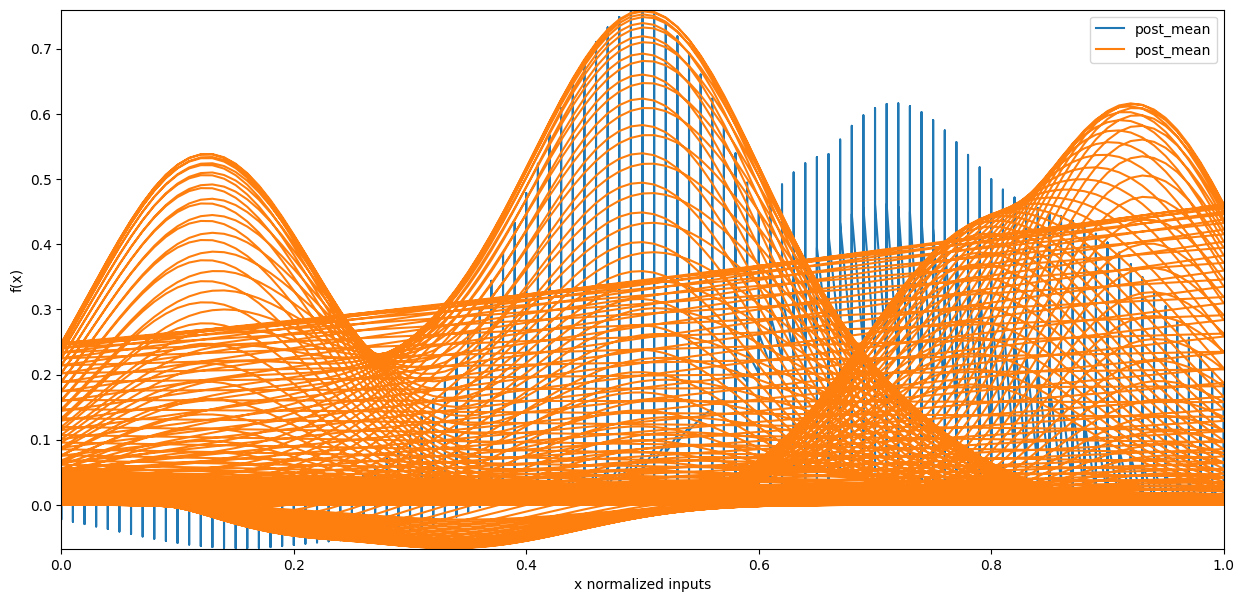

In [ ]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(0, 1)
ax.set_ylim(min(post_mean) - 0.001, max(post_mean) + 0.001)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
ax.plot(x_grid, post_mean,  label = 'post_mean')
#ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



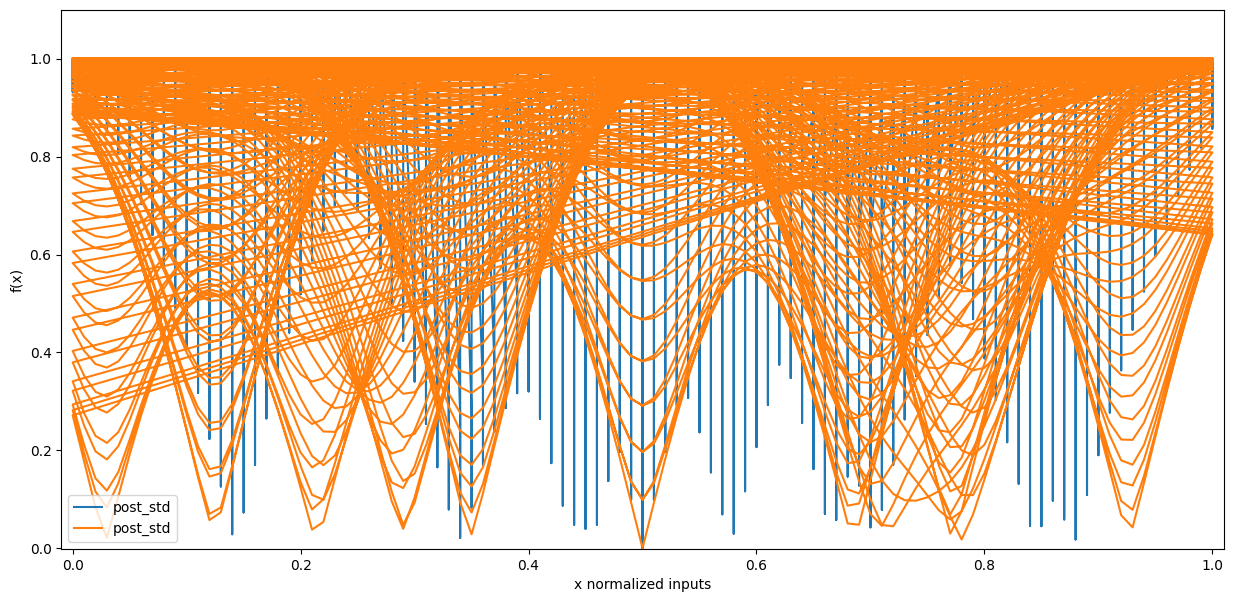

In [ ]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(post_std) - 0.001, max(post_std) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



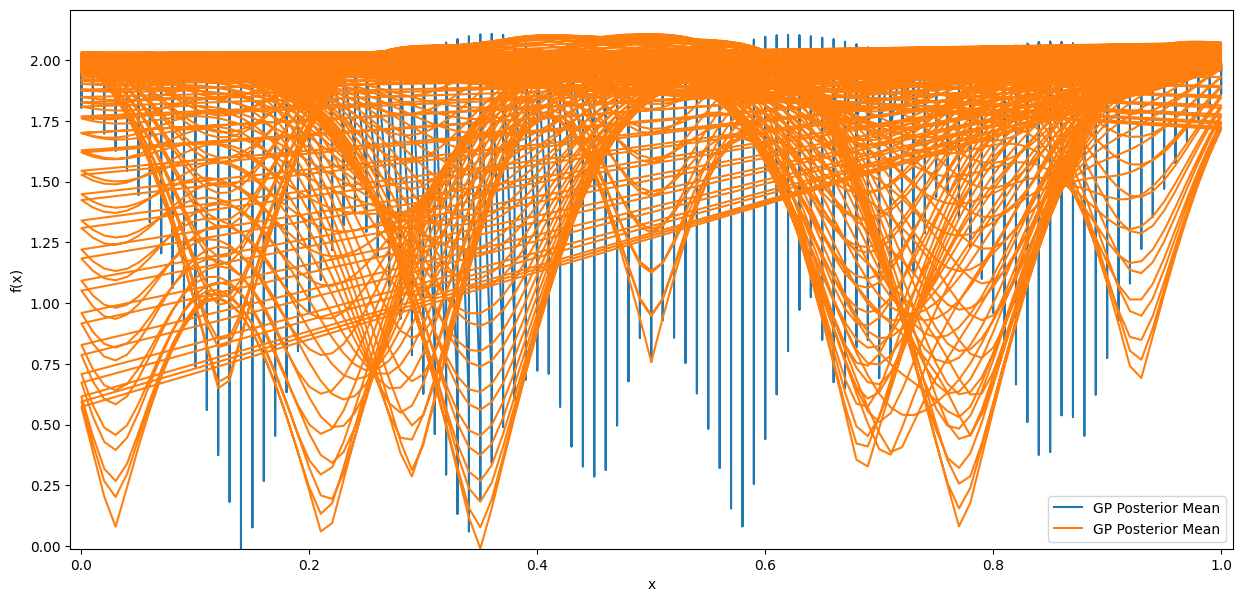

In [ ]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(acquisition_function) - 0.001, max(acquisition_function) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, acquisition_function,  label = 'GP Posterior Mean')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()

